# Digital addiction: what is linked to a social media addiction score?

Course: Python for Data Science (DSBA), 2025/2026.

Authors: Mitricheva Anna and Romanovskaia Eva, group 251.

## Abstract

This project looks at a dataset of 10000 social media users and tries to understand what is connected to a person's addiction score: the time they spend on TikTok and Instagram, their night usage, their age and their sleep. We describe the data, check its quality, compute basic statistics, clean and normalize it, add a few new columns, draw plots and finally test two hypotheses with scipy.

What we found is that the time spent on social media is the main thing linked to the addiction score, and TikTok is connected to it a bit more than Instagram. Age and sleep, on the other hand, are not related to the score at all. Contribution: Anna prepared and cleaned the data and wrote the statistics part, Eva made the plots and ran the hypothesis tests, and we wrote the text and conclusions together.

## 1. Setup

We import the libraries we need and set a soft pink and beige color theme for the plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler
from scipy import stats

pink = "#D98AA0"
mauve = "#C98BAE"
plum = "#9B6A8F"
beige = "#E4D2B8"
taupe = "#CBB293"
cream = "#FBF3EC"
ink = "#6E4B5E"
palette = ["#E7A6B0", "#D98AA0", "#C98BAE", "#E4D2B8", "#CBB293", "#9B6A8F"]

sns.set_theme(style="whitegrid")
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams["figure.facecolor"] = cream
plt.rcParams["axes.facecolor"] = cream
plt.rcParams["savefig.facecolor"] = cream
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

/Users/nigo57/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/nigo57/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 2. The dataset

The data is about social media use and digital addiction. Each row is one user with their daily TikTok and Instagram minutes, some behaviour indices (night usage, scroll speed, dopamine dependency, attention span), sleep, age and country, and a final addiction score with a level from Low to Severe.

In [2]:
df = pd.read_csv("data/data.csv")
print("Rows:", df.shape[0], "Columns:", df.shape[1])
df.head()

Rows: 10000 Columns: 23


,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,instagram_minutes_daily,night_usage_ratio,scroll_velocity,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
0,1,Philippines,59,2050,88.895513,64.347080,0.312067,0.310389,64.762693,242.853130,27.395222,0.260955,2.607246,69.981792,77.479304,27.024835,60.044856,6.561778,7.912360,100.0,40.460626,63.512418,High
1,2,Netherlands,23,2035,57.950292,76.257045,0.460320,0.293134,37.592646,98.599951,155.167494,0.963487,4.154875,56.862382,78.852713,25.376744,81.769114,9.400197,2.292106,100.0,79.424028,62.688372,High
2,3,Laos,26,2060,40.325805,55.846514,0.893658,0.183055,22.589595,127.221573,69.902284,0.961405,2.791170,41.817693,83.573012,19.712386,99.613065,7.810417,2.308761,100.0,88.262729,59.856193,High
3,4,Bulgaria,50,2046,43.838044,28.390576,0.661523,0.155038,57.093084,140.528514,58.219387,0.685945,3.952342,70.811984,83.437675,19.874790,86.935944,7.020033,4.512440,100.0,70.905771,59.937395,High
4,5,Zambia,24,2045,43.749943,81.413755,0.275186,0.457115,57.653485,187.748696,148.328575,0.716873,2.426045,71.990949,71.993561,33.607727,45.275020,7.900621,4.265014,100.0,51.312439,66.803864,High


The main fields we use:

| Field | Meaning |
|-------|---------|
| tiktok_minutes_daily, instagram_minutes_daily | minutes per day on each app |
| night_usage_ratio | share of usage at night, from 0 to 1 |
| attention_span_score | attention span |
| dopamine_dependency_score | dopamine dependency |
| sleep_hours | hours of sleep |
| age, country, year | who the user is |
| addiction_score | the numeric addiction score |
| addiction_level | Low, Medium, High or Severe |

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      10000 non-null  int64  
 1   country                      10000 non-null  str    
 2   age                          10000 non-null  int64  
 3   year                         10000 non-null  int64  
 4   internet_penetration         10000 non-null  float64
 5   mental_health_support_index  10000 non-null  float64
 6   gdp_index                    10000 non-null  float64
 7   youth_population_ratio       10000 non-null  float64
 8   baseline_addiction_pressure  10000 non-null  float64
 9   tiktok_minutes_daily         10000 non-null  float64
 10  instagram_minutes_daily      10000 non-null  float64
 11  night_usage_ratio            10000 non-null  float64
 12  scroll_velocity              10000 non-null  float64
 13  addiction_pressure          

### Data quality

We check for missing values, duplicates and strange types or ranges.

In [4]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Levels:", df["addiction_level"].unique().tolist())
print("Age from", df["age"].min(), "to", df["age"].max())
print("Year from", df["year"].min(), "to", df["year"].max())

Missing values: 0
Duplicate rows: 0
Levels: ['High', 'Medium', 'Low', 'Severe']
Age from 13 to 59
Year from 2015 to 2060


The dataset is clean. There are no missing values and no duplicates, and the types are correct. The year column is synthetic and goes up to 2060, which we just keep in mind.

## 3. Descriptive statistics

For the main numeric fields we show the mean, median and standard deviation, together with the range and quartiles.

In [5]:
num_fields = ["tiktok_minutes_daily", "instagram_minutes_daily", "sleep_hours", "addiction_score", "night_usage_ratio", "attention_span_score"]
desc = df[num_fields].describe().T
desc["median"] = df[num_fields].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
desc.round(2)

,count,mean,median,std,min,25%,75%,max
tiktok_minutes_daily,10000.0,120.92,120.42,58.32,0.00,79.61,161.26,356.31
instagram_minutes_daily,10000.0,100.11,99.61,49.32,0.00,66.10,133.42,277.10
sleep_hours,10000.0,7.00,6.99,1.46,3.00,5.99,8.04,10.00
addiction_score,10000.0,58.55,61.00,9.27,4.14,57.96,63.68,75.14
night_usage_ratio,10000.0,0.50,0.50,0.29,0.00,0.26,0.75,1.00
attention_span_score,10000.0,81.58,81.67,6.42,58.11,77.19,86.04,100.00


In [6]:
for c in num_fields:
    s = df[c]
    print(c, "mean", round(s.mean(), 2), "median", round(s.median(), 2), "std", round(s.std(), 2))

tiktok_minutes_daily mean 120.92 median 120.42 std 58.32
instagram_minutes_daily mean 100.11 median 99.61 std 49.32
sleep_hours mean 7.0 median 6.99 std 1.46
addiction_score mean 58.55 median 61.0 std 9.27
night_usage_ratio mean 0.5 median 0.5 std 0.29
attention_span_score mean 81.58 median 81.67 std 6.42


On average users spend about 121 minutes a day on TikTok and about 100 on Instagram. Sleep is around 7 hours and the addiction score is around 58. Night usage is spread fairly evenly between 0 and 1.

## 4. Data cleanup

The data is already clean, so we mainly show that it is clean, turn addiction_level into an ordered category and drop the user_id column, which is just an identifier.

In [7]:
data = df.copy()
data["addiction_level"] = pd.Categorical(data["addiction_level"], categories=["Low", "Medium", "High", "Severe"], ordered=True)
data = data.drop(columns=["user_id"])
print("Missing values:", int(data.isna().sum().sum()))
print("Duplicates:", int(data.duplicated().sum()))
print("Shape:", data.shape)

Missing values: 0
Duplicates: 0
Shape: (10000, 22)


## 5. New columns

Since the data did not need real cleaning, we add a few new columns built from the existing ones.

| New column | How it is built |
|------------|-----------------|
| total_minutes | tiktok_minutes_daily plus instagram_minutes_daily |
| daily_hours | total_minutes divided by 60 |
| tiktok_share | tiktok_minutes_daily divided by total_minutes |
| night_minutes | total_minutes times night_usage_ratio |
| age_group | age split into under 25, 25 to 35 and over 35 |
| heavy_user | 1 if total time is above the median, else 0 |
| level_num | addiction level as a number from 1 to 4 |

In [8]:
data["total_minutes"] = data["tiktok_minutes_daily"] + data["instagram_minutes_daily"]
data["daily_hours"] = data["total_minutes"] / 60
data["tiktok_share"] = data["tiktok_minutes_daily"] / data["total_minutes"].replace(0, np.nan)
data["night_minutes"] = data["total_minutes"] * data["night_usage_ratio"]
data["age_group"] = pd.cut(data["age"], bins=[0, 25, 35, 200], labels=["<25", "25-35", "35+"])
data["heavy_user"] = (data["total_minutes"] > data["total_minutes"].median()).astype(int)
data["level_num"] = data["addiction_level"].cat.codes + 1
data[["total_minutes", "daily_hours", "tiktok_share", "night_minutes", "age_group", "heavy_user", "level_num"]].head()

,total_minutes,daily_hours,tiktok_share,night_minutes,age_group,heavy_user,level_num
0,270.248352,4.504139,0.898629,70.522647,35+,1,3
1,253.767444,4.229457,0.388545,244.501578,<25,1,3
2,197.123856,3.285398,0.645389,189.515847,25-35,0,3
3,198.747901,3.312465,0.707069,136.330126,35+,0,3
4,336.077271,5.601288,0.558647,240.924796,<25,1,3


## 6. Normalization

The numeric fields are on very different scales (minutes go into the hundreds while ratios stay between 0 and 1). To make them comparable we standardize the main numeric columns to mean 0 and standard deviation 1 and keep the original columns for the readable plots.

In [9]:
scaled_cols = ["tiktok_minutes_daily", "instagram_minutes_daily", "total_minutes", "night_minutes", "sleep_hours", "addiction_score"]
for c in scaled_cols:
    data[c + "_z"] = (data[c] - data[c].mean()) / data[c].std()
data[[c + "_z" for c in scaled_cols]].describe().round(2).T[["mean", "std", "min", "max"]]

,mean,std,min,max
tiktok_minutes_daily_z,0.0,1.0,-2.07,4.04
instagram_minutes_daily_z,0.0,1.0,-2.03,3.59
total_minutes_z,0.0,1.0,-2.87,3.66
night_minutes_z,-0.0,1.0,-1.44,4.29
sleep_hours_z,0.0,1.0,-2.73,2.05
addiction_score_z,0.0,1.0,-5.87,1.79


After standardization every scaled column has a mean of about 0 and a standard deviation of about 1, which confirms the normalization worked.

## 7. Plots of single fields

We look at five numeric fields with three kinds of plots: histograms, a box plot and a scatter plot.

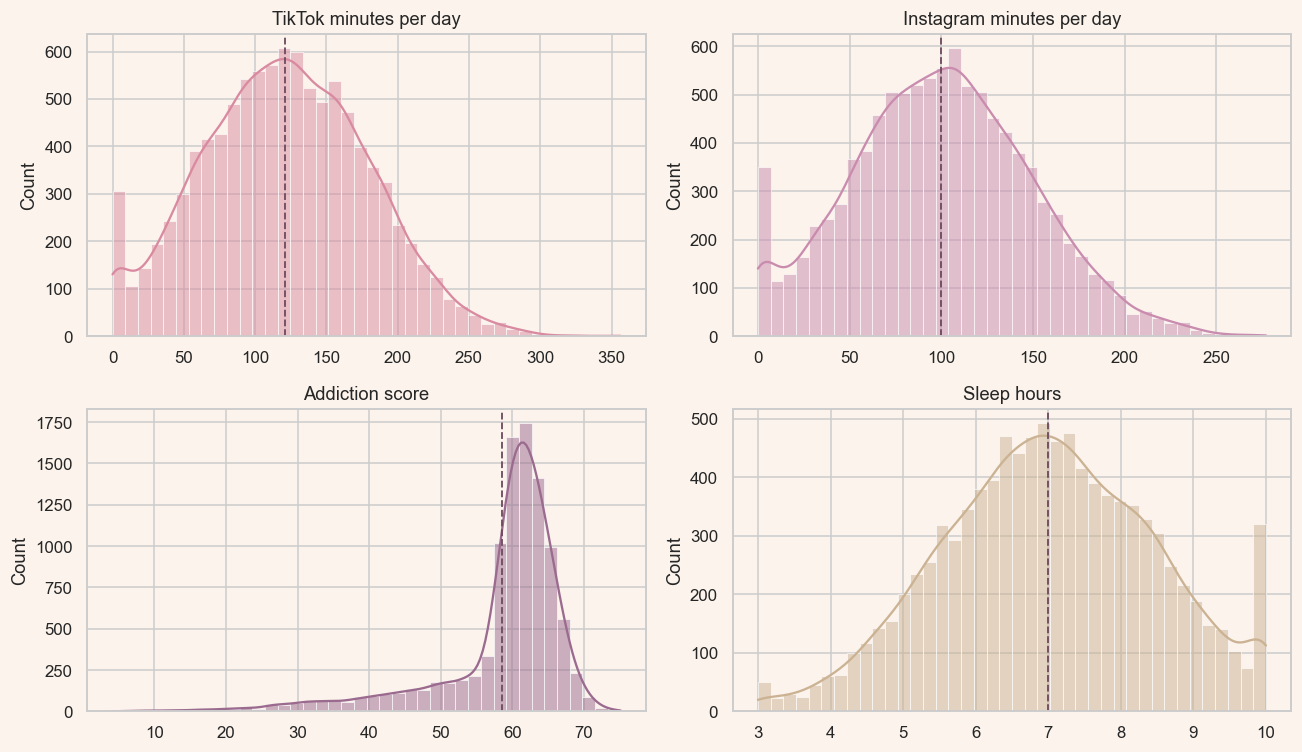

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
specs = [("tiktok_minutes_daily", "TikTok minutes per day", pink), ("instagram_minutes_daily", "Instagram minutes per day", mauve), ("addiction_score", "Addiction score", plum), ("sleep_hours", "Sleep hours", taupe)]
for ax, (col, title, color) in zip(axes.flat, specs):
    sns.histplot(data[col], bins=40, kde=True, color=color, ax=ax, edgecolor="white", linewidth=0.4)
    ax.axvline(data[col].mean(), color=ink, ls="--", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

/var/folders/kw/_9pfglz11tx4xxdg11jvtd_00000gn/T/ipykernel_33628/1634370708.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="addiction_level", y="total_minutes", order=["Low", "Medium", "High", "Severe"], palette=palette)
/var/folders/kw/_9pfglz11tx4xxdg11jvtd_00000gn/T/ipykernel_33628/1634370708.py:2: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.boxplot(data=data, x="addiction_level", y="total_minutes", order=["Low", "Medium", "High", "Severe"], palette=palette)


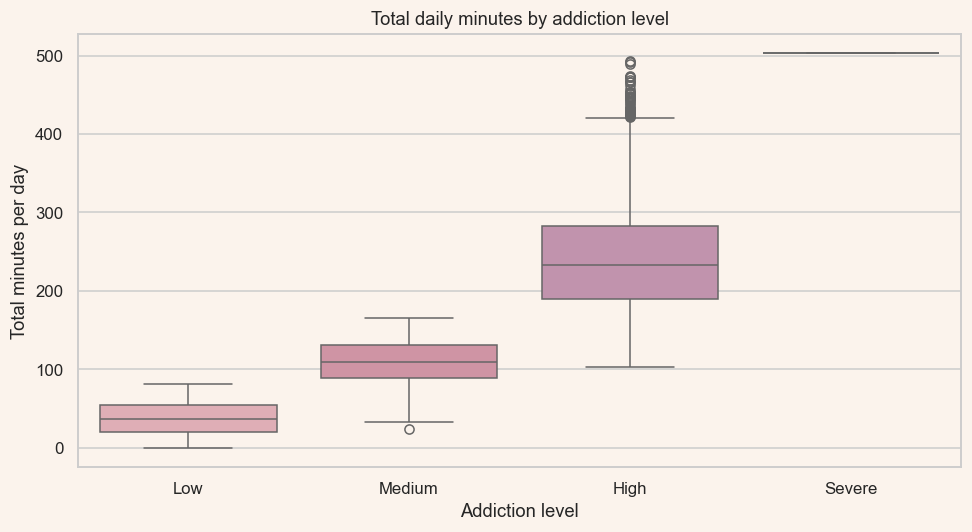

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="addiction_level", y="total_minutes", order=["Low", "Medium", "High", "Severe"], palette=palette)
plt.title("Total daily minutes by addiction level")
plt.xlabel("Addiction level")
plt.ylabel("Total minutes per day")
plt.tight_layout()
plt.show()

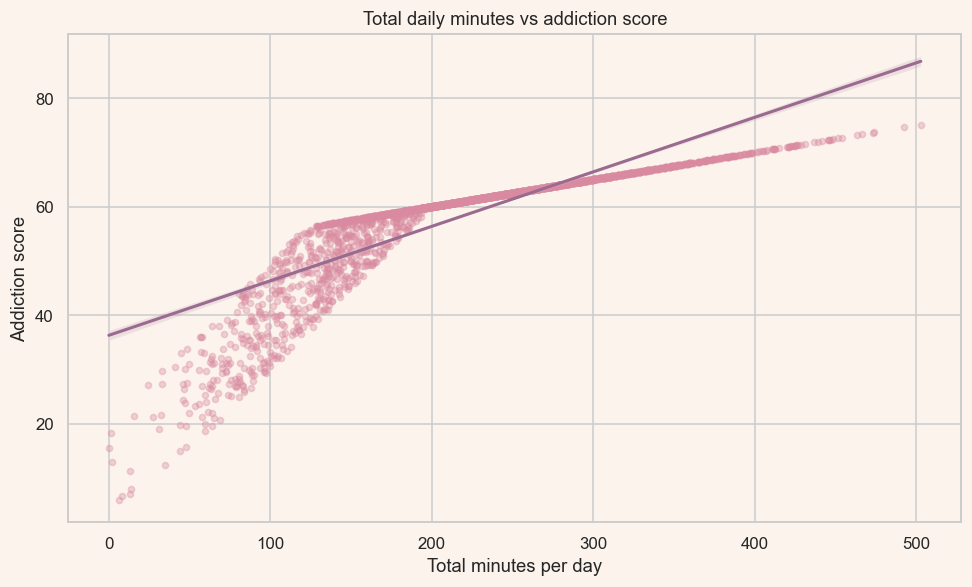

In [12]:
sample = data.sample(3000, random_state=1)
plt.figure(figsize=(9, 5.5))
sns.regplot(data=sample, x="total_minutes", y="addiction_score", scatter_kws={"alpha": 0.35, "s": 16, "color": pink}, line_kws={"color": plum, "lw": 2})
plt.title("Total daily minutes vs addiction score")
plt.xlabel("Total minutes per day")
plt.ylabel("Addiction score")
plt.tight_layout()
plt.show()

TikTok and Instagram minutes are roughly bell shaped, the addiction score sits around 55 to 65 and sleep is symmetric around 7 hours. The box plot shows total minutes rising sharply with the addiction level, and the scatter shows a clear upward trend between minutes and the score.

## 8. Comparisons and relationships

Here we compare fields and look for relationships.

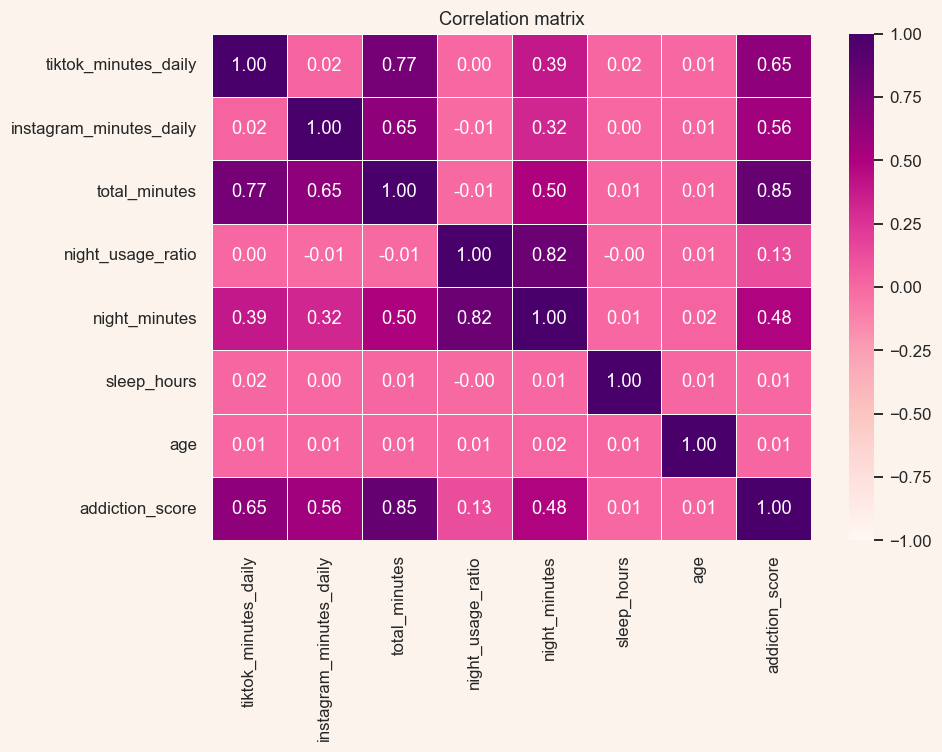

In [13]:
corr_cols = ["tiktok_minutes_daily", "instagram_minutes_daily", "total_minutes", "night_usage_ratio", "night_minutes", "sleep_hours", "age", "addiction_score"]
plt.figure(figsize=(9, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdPu", vmin=-1, vmax=1, linewidths=0.5, linecolor="white")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

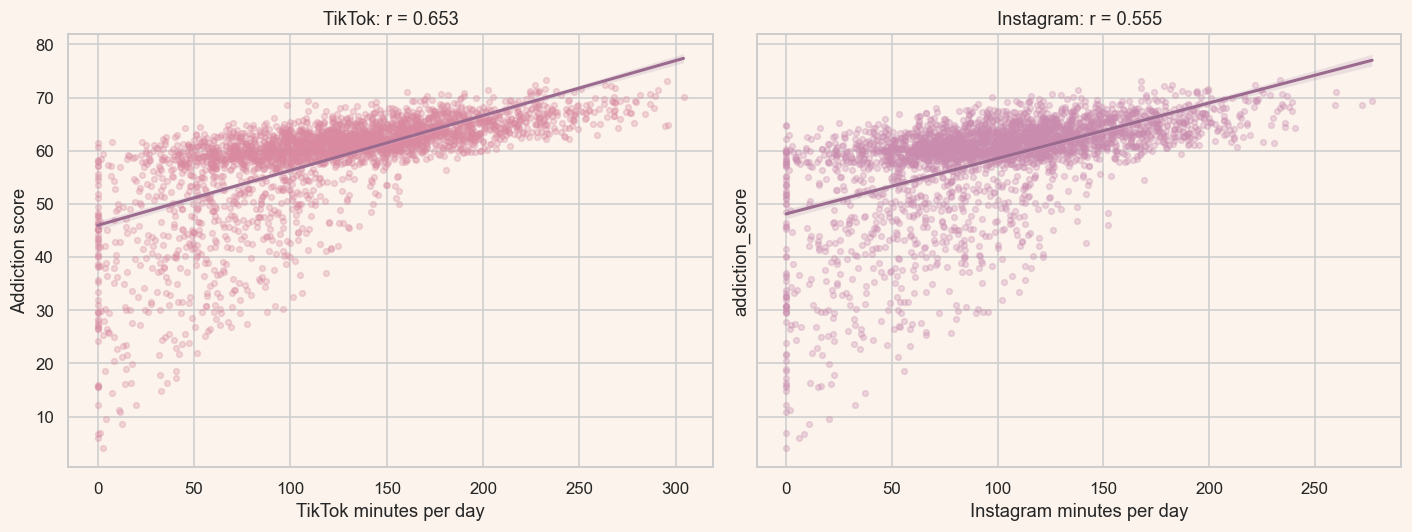

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col, title, color in zip(axes, ["tiktok_minutes_daily", "instagram_minutes_daily"], ["TikTok", "Instagram"], [pink, mauve]):
    s = data.sample(3000, random_state=2)
    sns.regplot(data=s, x=col, y="addiction_score", ax=ax, scatter_kws={"alpha": 0.3, "s": 14, "color": color}, line_kws={"color": plum, "lw": 2})
    r, p = stats.pearsonr(data[col], data["addiction_score"])
    ax.set_title(title + ": r = " + str(round(r, 3)))
    ax.set_xlabel(title + " minutes per day")
axes[0].set_ylabel("Addiction score")
plt.tight_layout()
plt.show()

/var/folders/kw/_9pfglz11tx4xxdg11jvtd_00000gn/T/ipykernel_33628/1346930840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="age_group", y="addiction_score", order=["<25", "25-35", "35+"], palette=palette)
/var/folders/kw/_9pfglz11tx4xxdg11jvtd_00000gn/T/ipykernel_33628/1346930840.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(data=data, x="age_group", y="addiction_score", order=["<25", "25-35", "35+"], palette=palette)


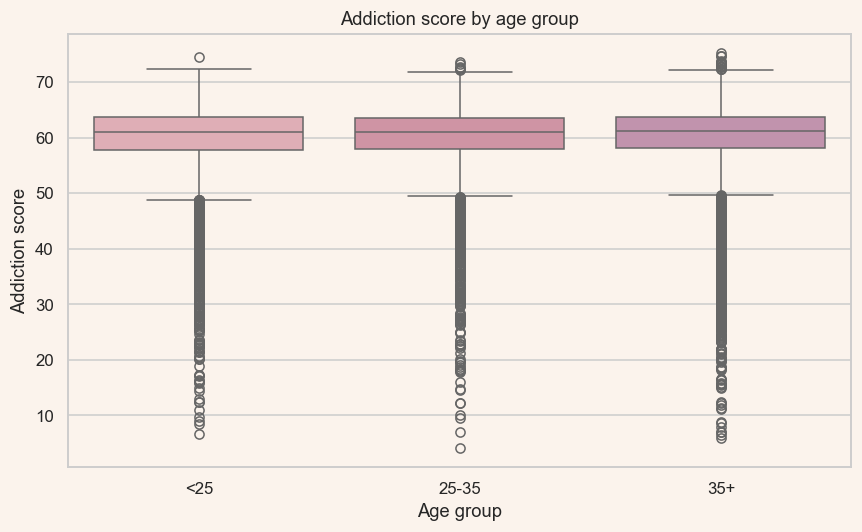

age_group
<25      58.38
25-35    58.45
35+      58.68
Name: addiction_score, dtype: float64


In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="age_group", y="addiction_score", order=["<25", "25-35", "35+"], palette=palette)
plt.title("Addiction score by age group")
plt.xlabel("Age group")
plt.ylabel("Addiction score")
plt.tight_layout()
plt.show()
print(data.groupby("age_group", observed=True)["addiction_score"].mean().round(2))

In [16]:
profile = data.groupby("addiction_level", observed=True).agg(n=("addiction_level", "size"), total_minutes=("total_minutes", "mean"), night_minutes=("night_minutes", "mean"), sleep_hours=("sleep_hours", "mean"), age=("age", "mean")).round(1)
profile

,n,total_minutes,night_minutes,sleep_hours,age
addiction_level,,,,,
Low,121,37.6,9.3,7.3,34.0
Medium,1198,108.6,39.0,6.9,35.7
High,8680,239.1,122.7,7.0,35.8
Severe,1,502.7,395.0,7.2,37.0


The correlation matrix makes the picture clear: the addiction score is strongly linked to total minutes and to the TikTok and Instagram minutes, while sleep and age sit close to zero. TikTok has a higher correlation than Instagram. The age groups have almost the same average score, and the profile table shows that higher addiction levels mostly mean a lot more daily and night minutes, not less sleep or a different age.

## 9. Hypotheses

We state two hypotheses and test each one with a plot and a statistical test from scipy, using a significance level of 0.05.

### Hypothesis 1: time drives addiction, and TikTok matters more than Instagram

We expect more daily time to go with a higher addiction score, and TikTok to matter a bit more than Instagram. We check the correlations and then fit a standardized linear regression so the two apps can be compared directly.

In [17]:
r_tt, p_tt = stats.pearsonr(data["tiktok_minutes_daily"], data["addiction_score"])
r_ig, p_ig = stats.pearsonr(data["instagram_minutes_daily"], data["addiction_score"])
r_tot, p_tot = stats.pearsonr(data["total_minutes"], data["addiction_score"])
print("TikTok r =", round(r_tt, 3), "p =", p_tt)
print("Instagram r =", round(r_ig, 3), "p =", p_ig)
print("Total r =", round(r_tot, 3), "p =", p_tot)
X = np.column_stack([np.ones(len(data)), data["tiktok_minutes_daily_z"], data["instagram_minutes_daily_z"]])
beta = np.linalg.lstsq(X, data["addiction_score_z"].values, rcond=None)[0]
print("Standardized coefficients: TikTok =", round(beta[1], 3), "Instagram =", round(beta[2], 3))

TikTok r = 0.653 p = 0.0
Instagram r = 0.555 p = 0.0
Total r = 0.85 p = 0.0
Standardized coefficients: TikTok = 0.644 Instagram = 0.545


/var/folders/kw/_9pfglz11tx4xxdg11jvtd_00000gn/T/ipykernel_33628/828690565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["TikTok", "Instagram", "Total"], y=[r_tt, r_ig, r_tot], palette=palette)
/var/folders/kw/_9pfglz11tx4xxdg11jvtd_00000gn/T/ipykernel_33628/828690565.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(x=["TikTok", "Instagram", "Total"], y=[r_tt, r_ig, r_tot], palette=palette)


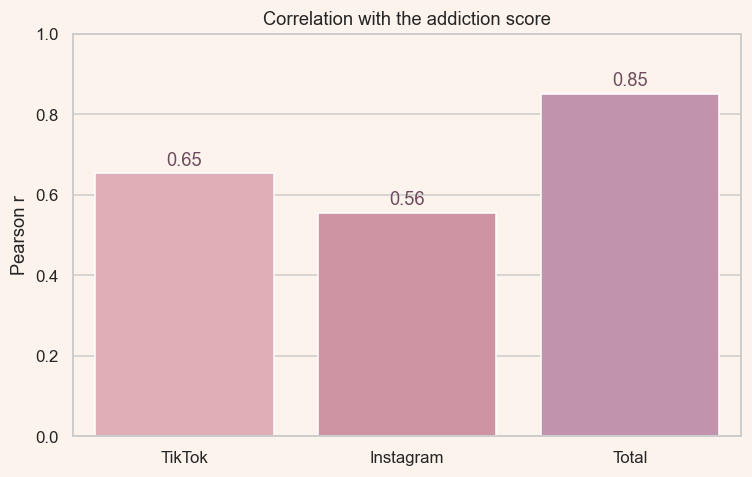

In [18]:
plt.figure(figsize=(7, 4.5))
sns.barplot(x=["TikTok", "Instagram", "Total"], y=[r_tt, r_ig, r_tot], palette=palette)
plt.title("Correlation with the addiction score")
plt.ylabel("Pearson r")
plt.ylim(0, 1)
for i, v in enumerate([r_tt, r_ig, r_tot]):
    plt.text(i, v + 0.02, round(v, 2), ha="center", color=ink)
plt.tight_layout()
plt.show()

The hypothesis holds. Both apps have a strong and significant correlation with the addiction score (p well below 0.05), the combined time even more so with r around 0.85, and the regression gives TikTok a larger coefficient than Instagram. So time clearly drives the score and TikTok matters a bit more, which we can also see in the two scatter plots above.

### Hypothesis 2: age and sleep are not related to the addiction score

A common idea is that young people or people who sleep less are more addicted. We expect the opposite to show in this data, that age and sleep have no real link to the score. We test both correlations and compare the youngest users (under 25) with the oldest (over 35).

In [19]:
r_age, p_age = stats.pearsonr(data["age"], data["addiction_score"])
r_sleep, p_sleep = stats.pearsonr(data["sleep_hours"], data["addiction_score"])
young = data[data["age"] < 25]["addiction_score"]
adult = data[data["age"] >= 35]["addiction_score"]
t, p_grp = stats.ttest_ind(young, adult, equal_var=False)
print("Age r =", round(r_age, 3), "p =", round(p_age, 3))
print("Sleep r =", round(r_sleep, 3), "p =", round(p_sleep, 3))
print("Mean score, young:", round(young.mean(), 2), "adults:", round(adult.mean(), 2))
print("t-test young vs adults: t =", round(t, 2), "p =", round(p_grp, 3))

Age r = 0.01 p = 0.295
Sleep r = 0.007 p = 0.498
Mean score, young: 58.38 adults: 58.67
t-test young vs adults: t = -1.3 p = 0.194


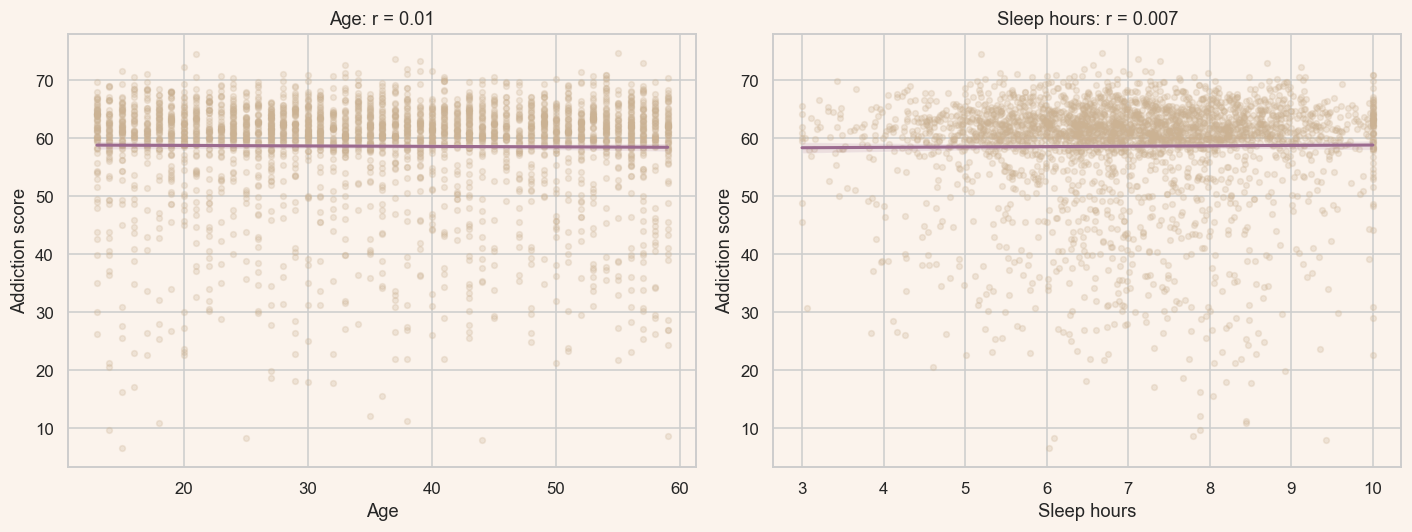

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
s = data.sample(3000, random_state=4)
for ax, col, title in zip(axes, ["age", "sleep_hours"], ["Age", "Sleep hours"]):
    sns.regplot(data=s, x=col, y="addiction_score", ax=ax, scatter_kws={"alpha": 0.25, "s": 14, "color": taupe}, line_kws={"color": plum, "lw": 2})
    r, p = stats.pearsonr(data[col], data["addiction_score"])
    ax.set_title(title + ": r = " + str(round(r, 3)))
    ax.set_xlabel(title)
    ax.set_ylabel("Addiction score")
plt.tight_layout()
plt.show()

The hypothesis holds. Both correlations are basically zero and not significant (the absolute value of r is about 0.01 with p well above 0.05), and the difference between young and older users is not significant either. The regression lines in the plots are almost flat. So in this data age and sleep do not explain the addiction score, which goes against the common assumption.

## 10. Conclusions

1. The time spent on social media is the main thing linked to the addiction score, with the total daily minutes reaching a correlation of about 0.85.
2. TikTok is connected to the score a little more than Instagram, both in the correlations and in the regression.
3. Age and sleep are not related to the addiction score at all, which is a clear result against the usual assumption.
4. Higher addiction levels mostly mean a lot more daily and night minutes, while sleep, age and country do not really matter here.

So if we want to understand a person's addiction score in this data, the useful signal is how much and how late they scroll, especially on TikTok, and not their age or how long they sleep.